# Depression Severity — EDA, Cleaning & Preprocessing

**Dataset**: Reddit Depression Severity Dataset (usmaann/Depression_Severity_Dataset)  
**Role in EmoCare**: Primary source for Low/Moderate/High **risk-tier grounding** (replaces DAIC-WOZ PHQ-8)  
**Labels**: 4-level severity — `Minimum` / `Mild` / `Moderate` / `Severe`  
**Mapping**: Minimum → Low | Mild → Low | Moderate → Moderate | Severe → High  
**Format**: Single CSV — `Reddit_depression_dataset.csv`

### Notebook Sections
0. Imports & Paths  
1. Load Raw Data  
2. EDA — Schema, Severity Distribution, Text Analysis  
3. Cleaning — Duplicates, Nulls, Label Normalisation  
4. Preprocessing — Risk tier mapping, text cleaning, linguistic markers  
5. Save to `data/processed/`

## 0. Imports & Paths

In [1]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ── Project paths ────────────────────────────────────────────
PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
RAW_DIR       = os.path.join(PROJECT_ROOT, 'data', 'raw', 'depression_severity')
INTERIM_DIR   = os.path.join(PROJECT_ROOT, 'data', 'interim')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
os.makedirs(INTERIM_DIR,   exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')

Project root : D:\EmoCare


## 1. Load Raw Data

In [2]:
df = pd.read_csv(os.path.join(RAW_DIR, 'Reddit_depression_dataset.csv'))
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (3553, 2)
Columns: ['text', 'label']


,text,label
0,"He said he had not felt that way before, sugge...",mild
1,"Hey there r/assistance, Not sure if this is th...",minimum
2,My mom then hit me with the newspaper and it s...,minimum
3,"until i met my new boyfriend, he is amazing, h...",mild
4,October is Domestic Violence Awareness Month a...,moderate


## 2. EDA — Schema, Severity Distribution, Text Analysis

In [3]:
print('=== Schema ===')
print(df.dtypes)
print()
print('=== Null counts ===')
print(df.isnull().sum())
print()
print('=== Sample ===')
df.sample(5, random_state=42)

=== Schema ===
text     str
label    str
dtype: object

=== Null counts ===
text     0
label    0
dtype: int64

=== Sample ===


,text,label
299,so i finally got tired of being anxious and de...,mild
3458,"My best friend died last year, of a rare type ...",minimum
1927,And I'll get an intense feeling of impending d...,moderate
486,"I am employed full time. I have money, but I a...",minimum
3025,"So I've had PTSD a few years now, coming up on...",minimum


In [4]:
# Identify the label column — common names in this dataset
# Adjust column name below if different in your version of the CSV
LABEL_COL = None
TEXT_COL  = None

for col in df.columns:
    if any(kw in col.lower() for kw in ['label', 'severity', 'class', 'level', 'depression']):
        print(f'Candidate label column: {col} — unique values: {df[col].unique()[:10]}')
        LABEL_COL = col
    if any(kw in col.lower() for kw in ['text', 'post', 'content', 'body', 'sentence']):
        print(f'Candidate text column : {col} — sample: {str(df[col].iloc[0])[:80]}')
        TEXT_COL = col

print(f'\nUsing LABEL_COL = {LABEL_COL!r}')
print(f'Using TEXT_COL  = {TEXT_COL!r}')

Candidate text column : text — sample: He said he had not felt that way before, suggeted I go rest and so ..TRIGGER AHE
Candidate label column: label — unique values: <ArrowStringArray>
['mild', 'minimum', 'moderate', 'severe']
Length: 4, dtype: str

Using LABEL_COL = 'label'
Using TEXT_COL  = 'text'


=== Severity Distribution ===
label
minimum     2587
moderate     394
mild         290
severe       282
Name: count, dtype: int64


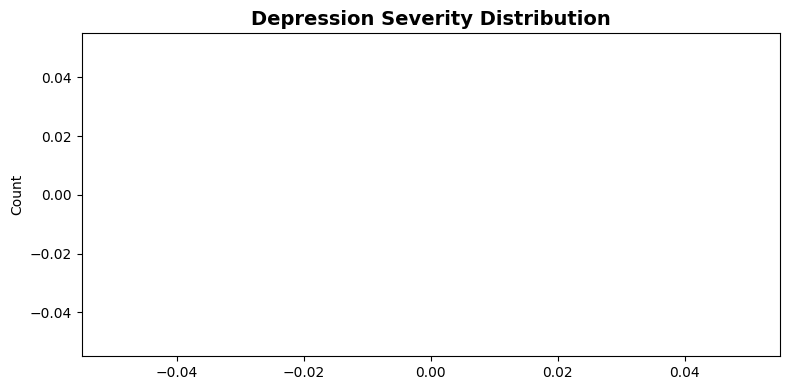

In [5]:
# ── MANUAL OVERRIDE if auto-detection is wrong ───────────────
# Uncomment and set manually if needed:
# LABEL_COL = 'label'
# TEXT_COL  = 'text'

# Severity distribution
print('=== Severity Distribution ===')
print(df[LABEL_COL].value_counts())

fig, ax = plt.subplots(figsize=(8, 4))
order = ['Minimum', 'Mild', 'Moderate', 'Severe']
counts = df[LABEL_COL].value_counts()
existing_order = [o for o in order if o in counts.index]
palette = {'Minimum': '#4CAF50', 'Mild': '#FFC107', 'Moderate': '#FF9800', 'Severe': '#F44336'}

bars = ax.bar(existing_order,
              [counts[o] for o in existing_order],
              color=[palette.get(o, 'gray') for o in existing_order])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontweight='bold')
ax.set_title('Depression Severity Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'depression_severity_dist.png'), dpi=150)
plt.show()

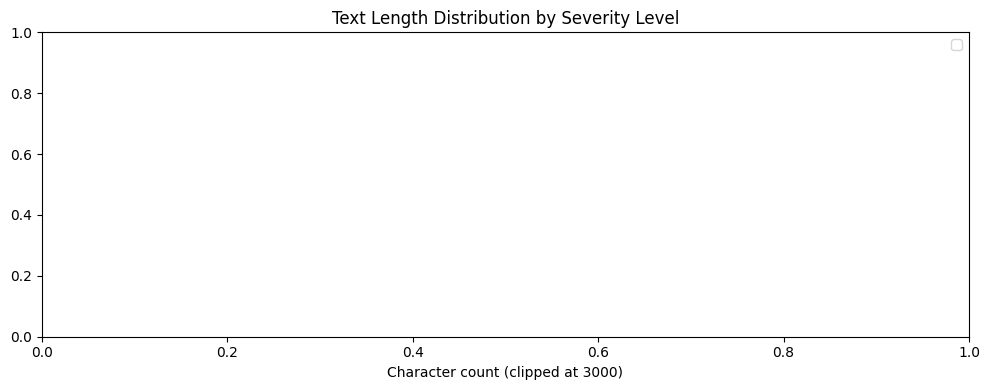

           count        mean         std    min    25%    50%     75%     max
label                                                                        
mild       290.0  477.755172  186.658076  154.0  366.0  450.0  554.50  1639.0
minimum   2587.0  441.445690  162.936027    6.0  335.0  418.0  520.00  1433.0
moderate   394.0  463.147208  169.473481  128.0  345.5  436.0  564.50  1606.0
severe     282.0  452.205674  185.975815  113.0  330.5  409.0  522.75  1358.0


In [6]:
# Text length by severity
df['text_len'] = df[TEXT_COL].astype(str).str.len()

fig, ax = plt.subplots(figsize=(10, 4))
for sev, color in [('Minimum', '#4CAF50'), ('Mild', '#FFC107'),
                   ('Moderate', '#FF9800'), ('Severe', '#F44336')]:
    subset = df[df[LABEL_COL] == sev]['text_len'].clip(upper=3000)
    if len(subset) > 0:
        subset.hist(bins=50, ax=ax, alpha=0.5, color=color, label=sev)
ax.set_title('Text Length Distribution by Severity Level')
ax.set_xlabel('Character count (clipped at 3000)')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby(LABEL_COL)['text_len'].describe())

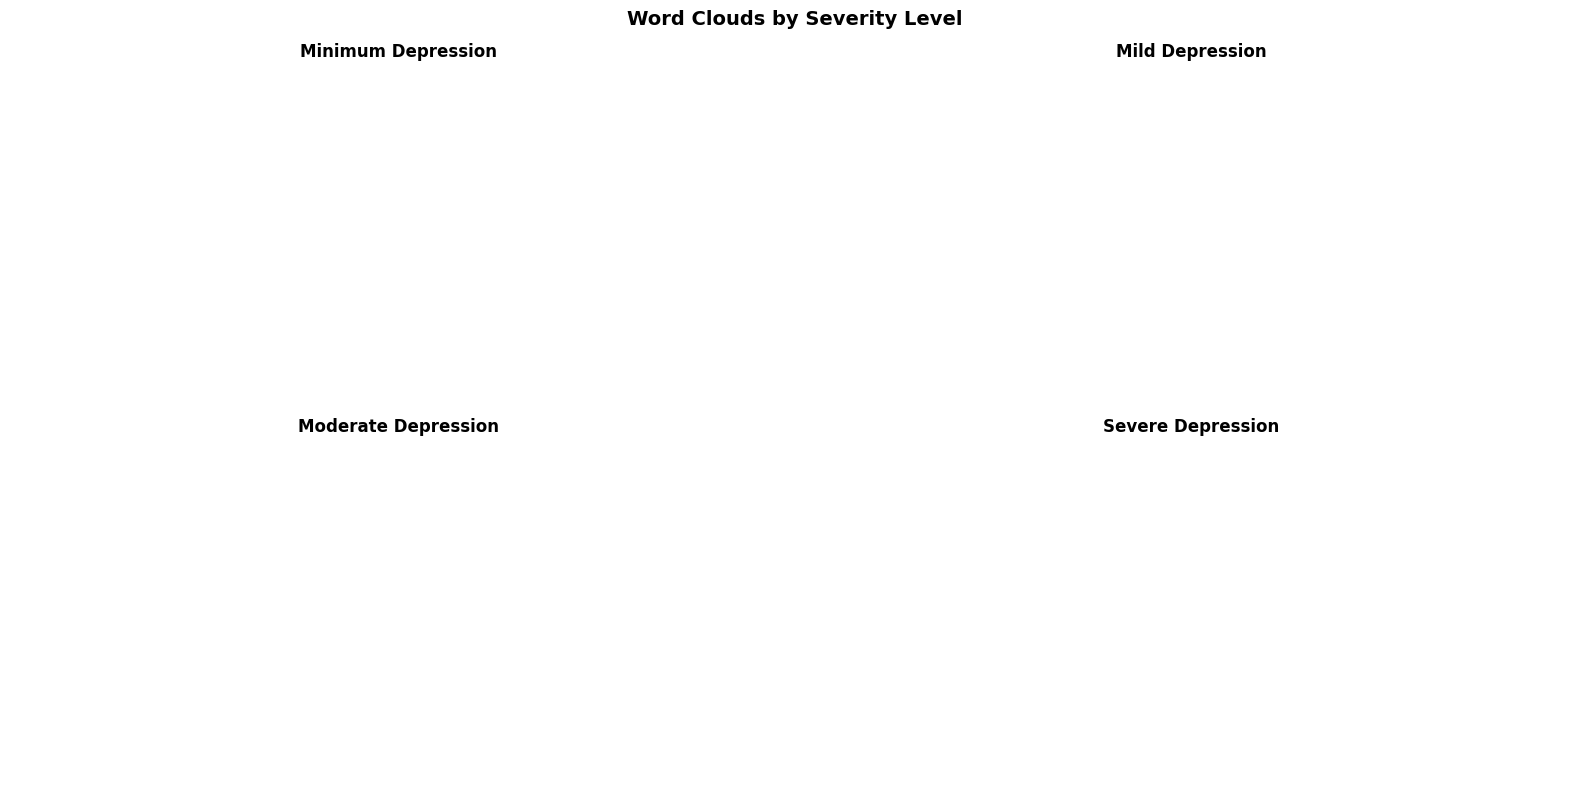

In [7]:
# Word clouds per severity
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
colors = ['Greens', 'YlOrBr', 'Oranges', 'Reds']

for i, (sev, cmap) in enumerate(zip(
    ['Minimum', 'Mild', 'Moderate', 'Severe'], colors)):
    text = ' '.join(df[df[LABEL_COL] == sev][TEXT_COL].dropna().astype(str).tolist())
    if text.strip():
        wc = WordCloud(width=600, height=350, background_color='white',
                       colormap=cmap, max_words=80).generate(text)
        axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'{sev} Depression', fontsize=12, fontweight='bold')
plt.suptitle('Word Clouds by Severity Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'depression_severity_wordclouds.png'), dpi=150)
plt.show()

## 3. Cleaning — Duplicates, Nulls, Label Normalisation

In [8]:
print(f'Rows before cleaning: {len(df)}')

# 3a. Duplicates
n_before = len(df)
df = df.drop_duplicates(subset=[TEXT_COL], keep='first')
print(f'Duplicates removed: {n_before - len(df)}')

# 3b. Null text
n_before = len(df)
df = df[df[TEXT_COL].notna() & (df[TEXT_COL].astype(str).str.strip() != '')]
print(f'Null/empty text removed: {n_before - len(df)}')

# 3c. Null labels
n_before = len(df)
df = df[df[LABEL_COL].notna()]
print(f'Null labels removed: {n_before - len(df)}')

# 3d. Normalise label case (handle variants like 'minimum', 'MINIMUM')
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.capitalize()
print(f'\nNormalised labels: {df[LABEL_COL].unique()}')
print(f'Rows after cleaning: {len(df)}')

Rows before cleaning: 3553
Duplicates removed: 21
Null/empty text removed: 0
Null labels removed: 0

Normalised labels: <ArrowStringArray>
['Mild', 'Minimum', 'Moderate', 'Severe']
Length: 4, dtype: str
Rows after cleaning: 3532


## 4. Preprocessing — Risk Tier Mapping & Text Cleaning

**Risk tier mapping rationale**: DepSeverity's 4-level scheme maps to our 3-tier system as follows:  
- `Minimum` → **Low** (PHQ-9 score 0–4 equivalent)  
- `Mild` → **Low** (PHQ-9 score 5–9; borderline, still low-risk for early intervention)  
- `Moderate` → **Moderate** (PHQ-9 score 10–14)  
- `Severe` → **High** (PHQ-9 score 15–27)  

This is the documented substitution for the dropped DAIC-WOZ PHQ-8 grounding.

=== Risk Tier Distribution ===
risk_tier
Low         2857
Moderate     394
High         281
Name: count, dtype: int64



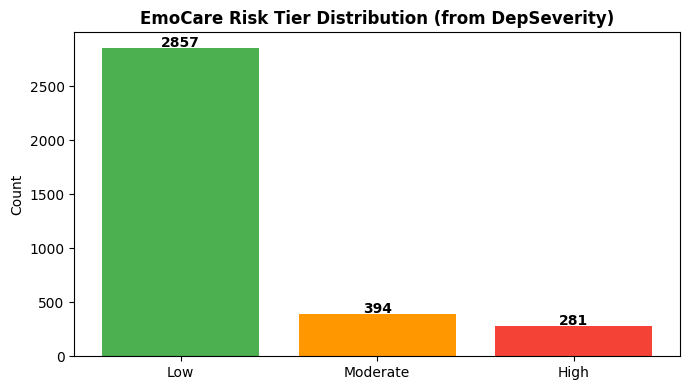

In [9]:
# Risk tier mapping
SEVERITY_TO_RISK = {
    'Minimum': 'Low',
    'Mild':    'Low',
    'Moderate':'Moderate',
    'Severe':  'High'
}

df['severity_label'] = df[LABEL_COL]  # keep original
df['risk_tier']      = df[LABEL_COL].map(SEVERITY_TO_RISK)

# Also create numeric encoding for modeling
RISK_TO_INT = {'Low': 0, 'Moderate': 1, 'High': 2}
df['risk_label'] = df['risk_tier'].map(RISK_TO_INT)

print('=== Risk Tier Distribution ===')
print(df['risk_tier'].value_counts())
print()

fig, ax = plt.subplots(figsize=(7, 4))
colors_risk = {'Low': '#4CAF50', 'Moderate': '#FF9800', 'High': '#F44336'}
risk_counts = df['risk_tier'].value_counts()
for tier in ['Low', 'Moderate', 'High']:
    if tier in risk_counts:
        ax.bar(tier, risk_counts[tier], color=colors_risk[tier])
        ax.text(tier, risk_counts[tier] + 5, str(risk_counts[tier]),
                ha='center', fontweight='bold')
ax.set_title('EmoCare Risk Tier Distribution (from DepSeverity)', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'depression_risk_tier_dist.png'), dpi=150)
plt.show()

In [10]:
# Text cleaning
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'u/\w+|r/\w+', '', text)
    text = re.sub(r'[^\w\s\'\"!?.,;:-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df[TEXT_COL].apply(clean_text)

# Drop very short texts
n_before = len(df)
df = df[df['text_clean'].str.len() >= 10]
print(f'Short text removed: {n_before - len(df)} | Remaining: {len(df)}')

Short text removed: 1 | Remaining: 3531


In [11]:
# Class imbalance analysis — key for SMOTE/class-weight decisions in modeling
risk_counts = df['risk_tier'].value_counts()
majority    = risk_counts.max()
print('=== Imbalance Analysis ===')
for tier in ['Low', 'Moderate', 'High']:
    if tier in risk_counts:
        ratio = majority / risk_counts[tier]
        print(f'  {tier:10s}: {risk_counts[tier]:5d} samples | imbalance ratio: {ratio:.1f}:1')

print()
print('NOTE: High imbalance on High/Moderate tiers → SMOTE or class_weight="balanced" in RF/XGBoost')

=== Imbalance Analysis ===
  Low       :  2856 samples | imbalance ratio: 1.0:1
  Moderate  :   394 samples | imbalance ratio: 7.2:1
  High      :   281 samples | imbalance ratio: 10.2:1

NOTE: High imbalance on High/Moderate tiers → SMOTE or class_weight="balanced" in RF/XGBoost


In [12]:
# Train / val / test split (stratified)
from sklearn.model_selection import train_test_split

df_temp, df_test = train_test_split(df, test_size=0.15, stratify=df['risk_label'], random_state=42)
df_train, df_val = train_test_split(df_temp, test_size=0.15, stratify=df_temp['risk_label'], random_state=42)

df_train = df_train.copy()
df_val   = df_val.copy()
df_test  = df_test.copy()
df_train['split'] = 'train'
df_val['split']   = 'val'
df_test['split']  = 'test'

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print()
print('Risk tier per split:')
print(df_all.groupby(['split', 'risk_tier']).size().unstack())

Train: 2,550 | Val: 451 | Test: 530

Risk tier per split:
risk_tier  High   Low  Moderate
split                          
test         42   429        59
train       203  2062       285
val          36   365        50


In [13]:
# Final columns
keep_cols = [TEXT_COL, 'text_clean', 'severity_label', 'risk_tier', 'risk_label', 'split']
df_processed = df_all[[c for c in keep_cols if c in df_all.columns]].copy()
df_processed = df_processed.rename(columns={TEXT_COL: 'text'})
print(f'Final shape: {df_processed.shape}')
df_processed.head()

Final shape: (3531, 6)


,text,text_clean,severity_label,risk_tier,risk_label,split
0,I'm so scared I actually don't want to lose hi...,i'm so scared i actually don't want to lose hi...,Minimum,Low,0,train
1,"We've known each other for 9 years, were FWB ...","we've known each other for 9 years, were fwb f...",Minimum,Low,0,train
2,I drove the 10 minutes home with my fiance on ...,i drove the 10 minutes home with my fiance on ...,Moderate,Moderate,1,train
3,"As an aside, it really kind of messes you up w...","as an aside, it really kind of messes you up w...",Minimum,Low,0,train
4,"I meet a great guy, we connect immediately due...","i meet a great guy, we connect immediately due...",Minimum,Low,0,train


## 5. Save to `data/processed/`

In [14]:
out_path = os.path.join(PROCESSED_DIR, 'depression_severity_processed.csv')
df_processed.to_csv(out_path, index=False)
print(f'Saved {len(df_processed):,} rows → {out_path}')

for split_name in ['train', 'val', 'test']:
    split_df = df_processed[df_processed['split'] == split_name]
    split_path = os.path.join(PROCESSED_DIR, f'depression_severity_{split_name}.csv')
    split_df.to_csv(split_path, index=False)
    print(f'  {split_name}: {len(split_df):,} rows → {split_path}')

Saved 3,531 rows → D:\EmoCare\data\processed\depression_severity_processed.csv


  train: 2,550 rows → D:\EmoCare\data\processed\depression_severity_train.csv
  val: 451 rows → D:\EmoCare\data\processed\depression_severity_val.csv
  test: 530 rows → D:\EmoCare\data\processed\depression_severity_test.csv


In [15]:
df_check = pd.read_csv(os.path.join(PROCESSED_DIR, 'depression_severity_processed.csv'))
print(df_check.shape)
print(df_check['risk_tier'].value_counts())
df_check.head(3)

(3531, 6)
risk_tier
Low         2856
Moderate     394
High         281
Name: count, dtype: int64


,text,text_clean,severity_label,risk_tier,risk_label,split
0,I'm so scared I actually don't want to lose hi...,i'm so scared i actually don't want to lose hi...,Minimum,Low,0,train
1,"We've known each other for 9 years, were FWB ...","we've known each other for 9 years, were fwb f...",Minimum,Low,0,train
2,I drove the 10 minutes home with my fiance on ...,i drove the 10 minutes home with my fiance on ...,Moderate,Moderate,1,train
